In [3]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer

Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


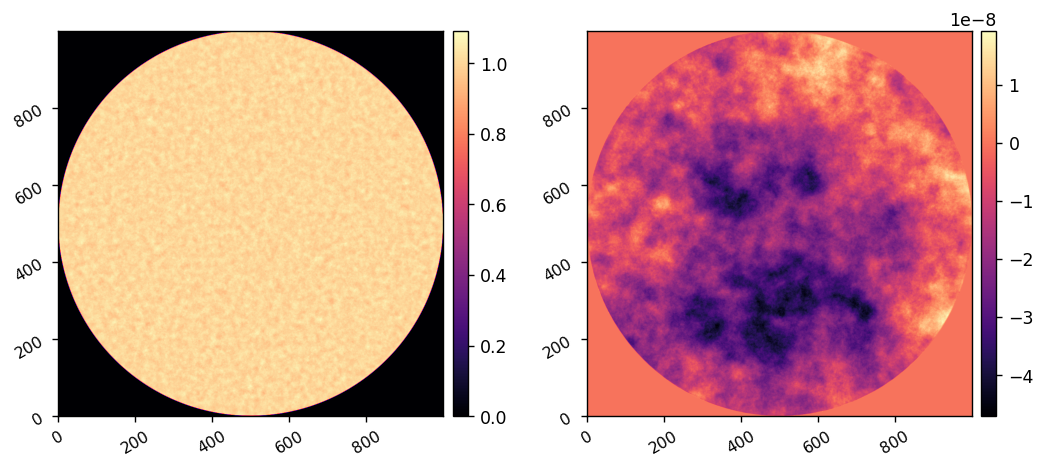

In [4]:
reload(fresnel)
I = fresnel.CORO(
    dm1_gains=1 + 0.02*xp.random.randn(96,96),
    dm2_gains=1 + 0.02*xp.random.randn(96,96),
    inf_fun_coupling=0.17,
    dm1_shift=np.array([75, 75 ])*u.um,
    dm2_shift=np.array([-75, -75 ])*u.um,
    lyot_shift=np.array([-75, 75 ])*u.um,
    # dm1_ref=dm1_flat,
)
I.use_opds = True

AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

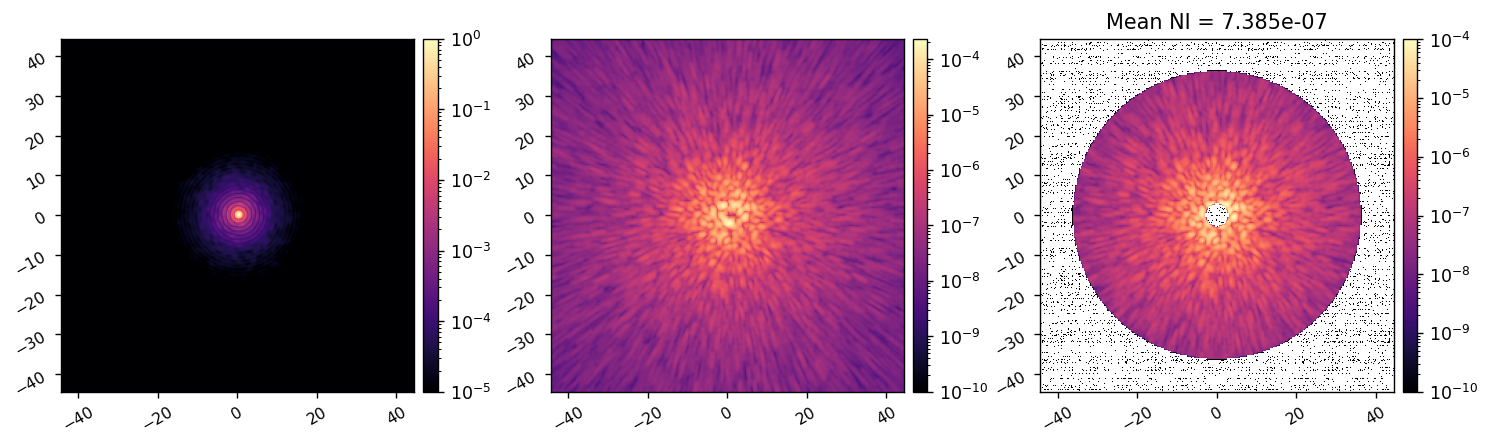

In [5]:
reload(fresnel)
I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 36
rot = 0
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=None, rotation=rot)
# control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)


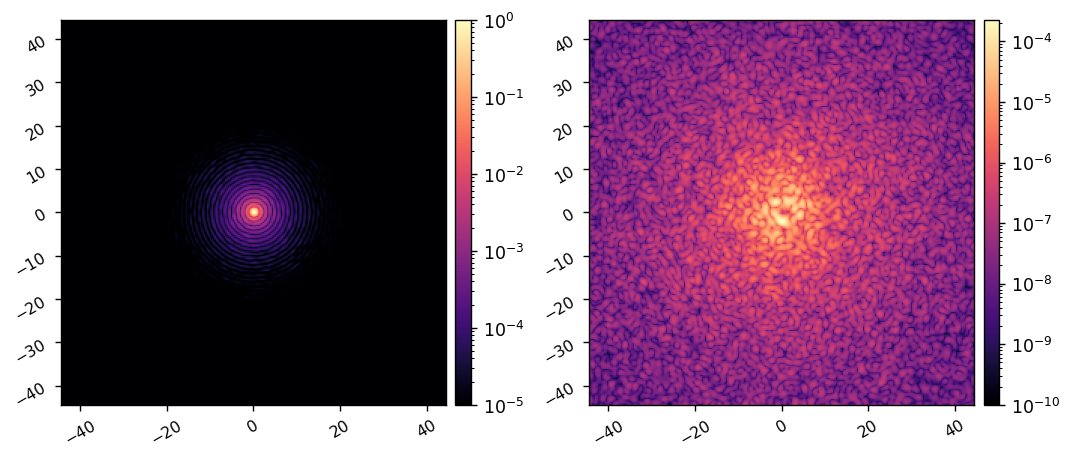

In [6]:
reload(fraunhofer)
M = fraunhofer.MODEL()
M.AMP = AMP
M.OPD = OPD

M.flip_dm = True
M.flip_lyot = True

acts = xp.zeros(M.Nacts)

model_psf = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=0) )**2
M.setattr('Imax_ref', xp.max(model_psf))
model_psf /= M.Imax_ref

model_coro_im = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=1) )**2

imshow2(model_psf, model_coro_im,
        pxscl=M.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)

In [26]:
I.reset_dms()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'dm1_commands':[],
    'del_dm1_commands':[],
    'dm2_commands':[],
    'del_dm2_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  7.89057D+06


 This problem is unconstrained.



At iterate    1    f=  8.70282D-01    |proj g|=  5.28044D+06

At iterate    2    f=  6.71027D-01    |proj g|=  1.77092D+06

At iterate    3    f=  6.38951D-01    |proj g|=  2.13306D+06

At iterate    4    f=  6.18829D-01    |proj g|=  1.11648D+06

At iterate    5    f=  6.09806D-01    |proj g|=  7.32522D+05

At iterate    6    f=  5.99128D-01    |proj g|=  1.14653D+06

At iterate    7    f=  5.97879D-01    |proj g|=  1.09913D+06

At iterate    8    f=  5.93340D-01    |proj g|=  4.54975D+05

At iterate    9    f=  5.92131D-01    |proj g|=  2.18326D+05

At iterate   10    f=  5.91827D-01    |proj g|=  2.56584D+05

At iterate   11    f=  5.91388D-01    |proj g|=  2.06663D+05

At iterate   12    f=  5.91111D-01    |proj g|=  1.50707D+05

At iterate   13    f=  5.90942D-01    |proj g|=  1.12145D+05

At iterate   14    f=  5.90865D-01    |proj g|=  1.27386D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments 

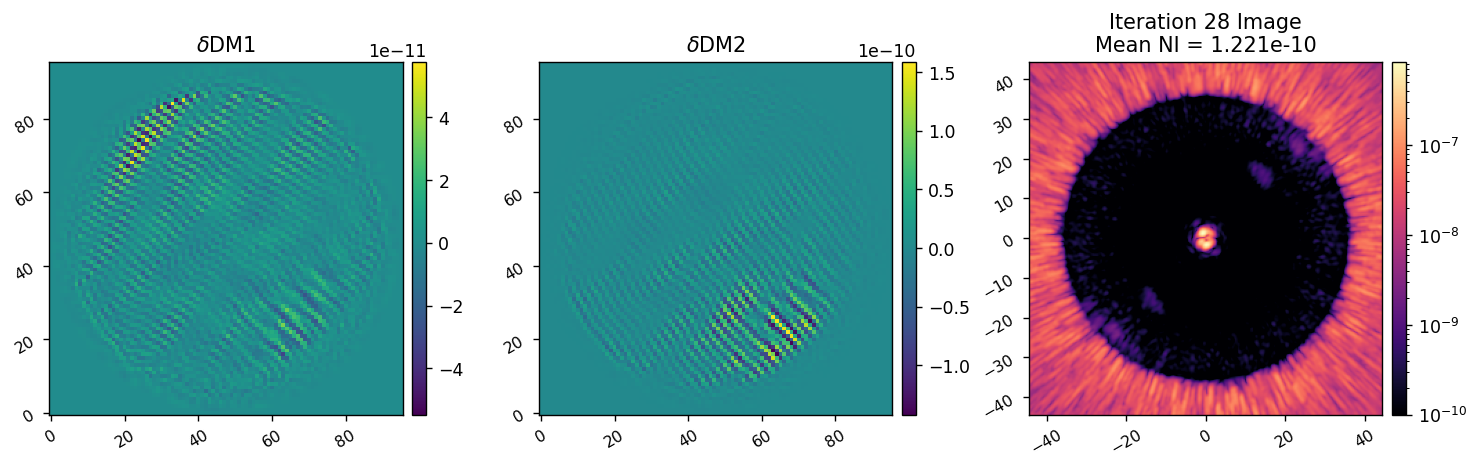

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  6.39426D+06


 This problem is unconstrained.



At iterate    1    f=  8.22223D-01    |proj g|=  3.58684D+06

At iterate    2    f=  6.77451D-01    |proj g|=  1.78875D+06

At iterate    3    f=  6.60660D-01    |proj g|=  2.17279D+06

At iterate    4    f=  6.34139D-01    |proj g|=  1.07281D+06

At iterate    5    f=  6.28152D-01    |proj g|=  6.73182D+05

At iterate    6    f=  6.19751D-01    |proj g|=  9.81936D+05

At iterate    7    f=  6.13425D-01    |proj g|=  8.78150D+05

At iterate    8    f=  6.13319D-01    |proj g|=  4.67183D+05

At iterate    9    f=  6.11634D-01    |proj g|=  2.21549D+05

At iterate   10    f=  6.10902D-01    |proj g|=  2.97181D+05

At iterate   11    f=  6.10434D-01    |proj g|=  2.71077D+05

At iterate   12    f=  6.10362D-01    |proj g|=  2.60373D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized 

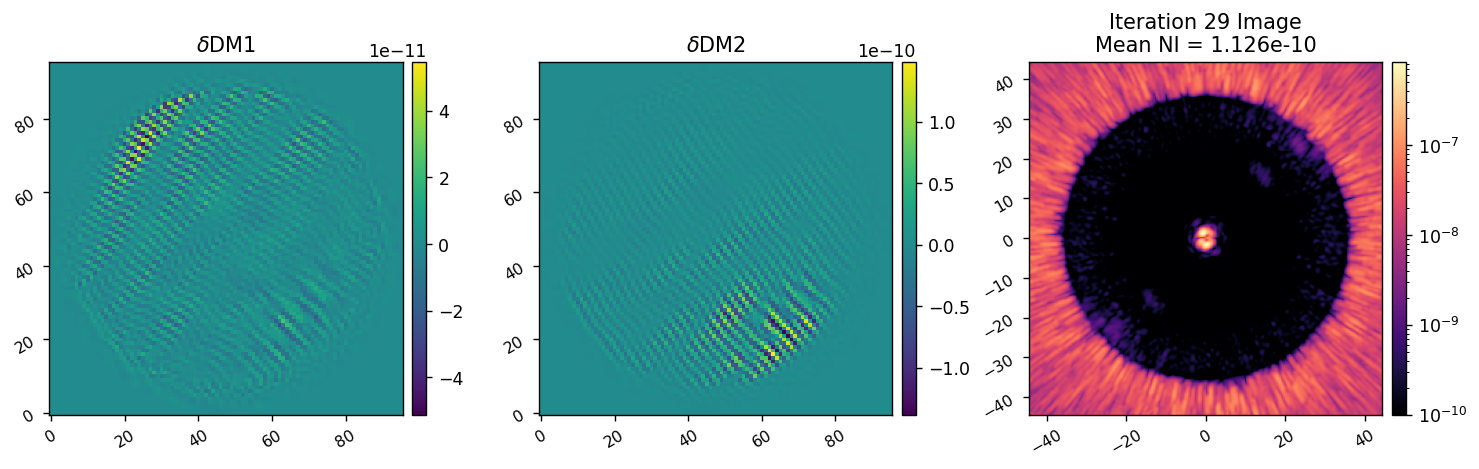

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  6.07842D+06


 This problem is unconstrained.



At iterate    1    f=  9.64483D-01    |proj g|=  8.73798D+06

At iterate    2    f=  7.15883D-01    |proj g|=  2.20245D+06

At iterate    3    f=  6.95745D-01    |proj g|=  1.05493D+06

At iterate    4    f=  6.82260D-01    |proj g|=  1.01783D+06

At iterate    5    f=  6.73228D-01    |proj g|=  1.24102D+06

At iterate    6    f=  6.67519D-01    |proj g|=  8.19312D+05

At iterate    7    f=  6.64203D-01    |proj g|=  5.53142D+05

At iterate    8    f=  6.61694D-01    |proj g|=  3.60015D+05

At iterate    9    f=  6.60630D-01    |proj g|=  4.08785D+05

At iterate   10    f=  6.60607D-01    |proj g|=  2.08082D+05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

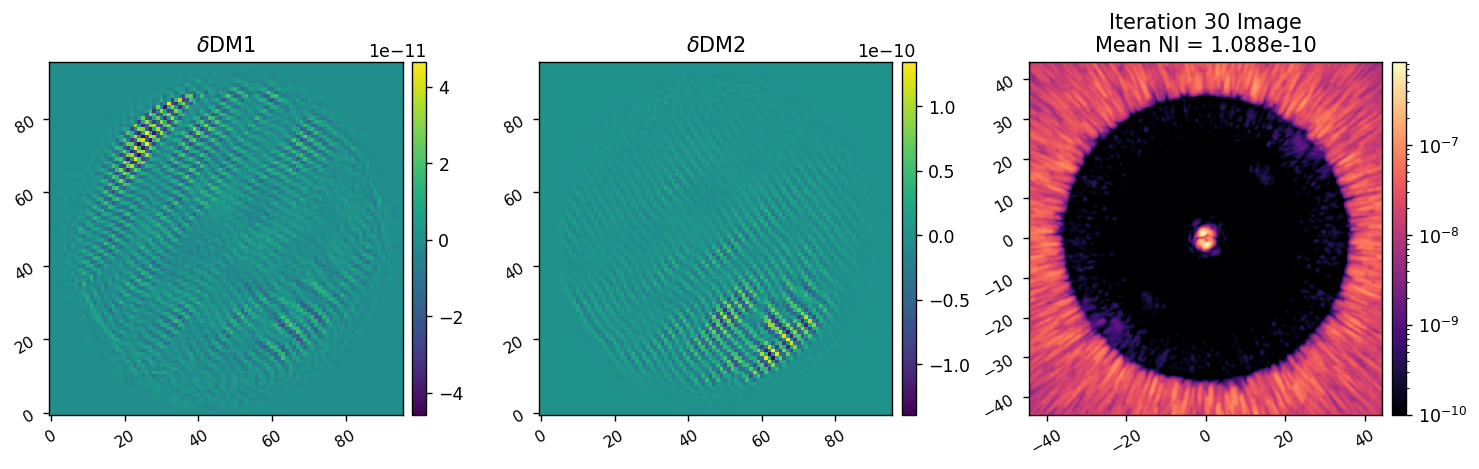

In [37]:
reload(fraunhofer)
reload(aefc)

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5
# bfgs_tol = 1e-10

bfgs_opts = {
    'disp':True,
    'maxls':10, 
    'maxiter':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run_bb(
    I, 
    M, 
    fraunhofer.val_and_grad_bb, 
    control_mask, 
    data,
    # Nitr=3, reg_cond=1e-1,
    Nitr=3, reg_cond=1e-2,
    # Nitr=3, reg_cond=5e-3,
    # Nitr=3, reg_cond=1e-4,
    # Nitr=3, reg_cond=1e-5,
    # Nitr=3, reg_cond=1e-6,
    # Nitr=3, reg_cond=1e-7,
    # Nitr=3, reg_cond=1e-8,
    # Nitr=3, reg_cond=1e-12,
    # weights=np.array([20,1,20]), 
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)



In [18]:
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
utils.save_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{today}_aefc_run_with_ME.pkl', data)
# utils.save_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{today}_aefc_run_with_ME_2.pkl', data)

Saved data to:  /npool/nvme/kianmilani/aefc-vortex-data/20250429_aefc_run_with_ME.pkl


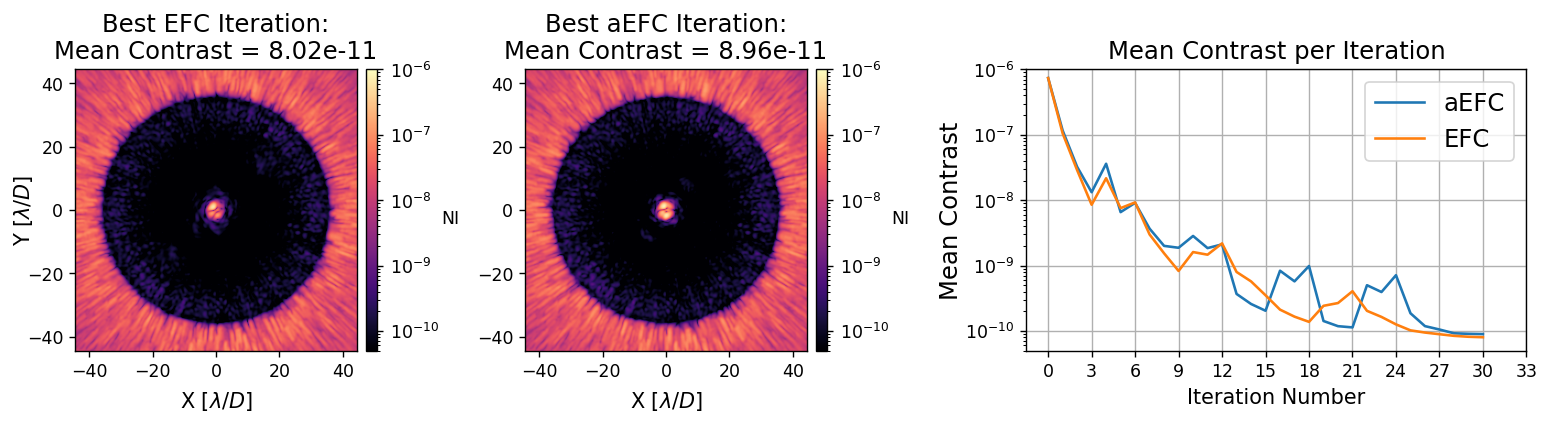

In [18]:

# efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241203}_efc_run_with_ME.pkl')
efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241220}_efc_run_with_ME_2.pkl')

# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241204}_aefc_run_with_ME_2.pkl')
# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241220}_aefc_run_with_ME_2.pkl')

# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250205}_aefc_run_with_ME.pkl')

# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250307}_aefc_run_with_ME.pkl')
# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250307}_aefc_run_with_ME_2.pkl')

aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250310}_aefc_run_with_ME.pkl')

import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_both_data(
    efc_data,  aefc_data,
    im1vmin=5e-11, im1vmax=1e-6, 
    im2vmin=5e-11, im2vmax=1e-6, 
    vmin=5e-11, vmax=1e-6,
    xticks=np.arange(0,33+0.1,3),
)

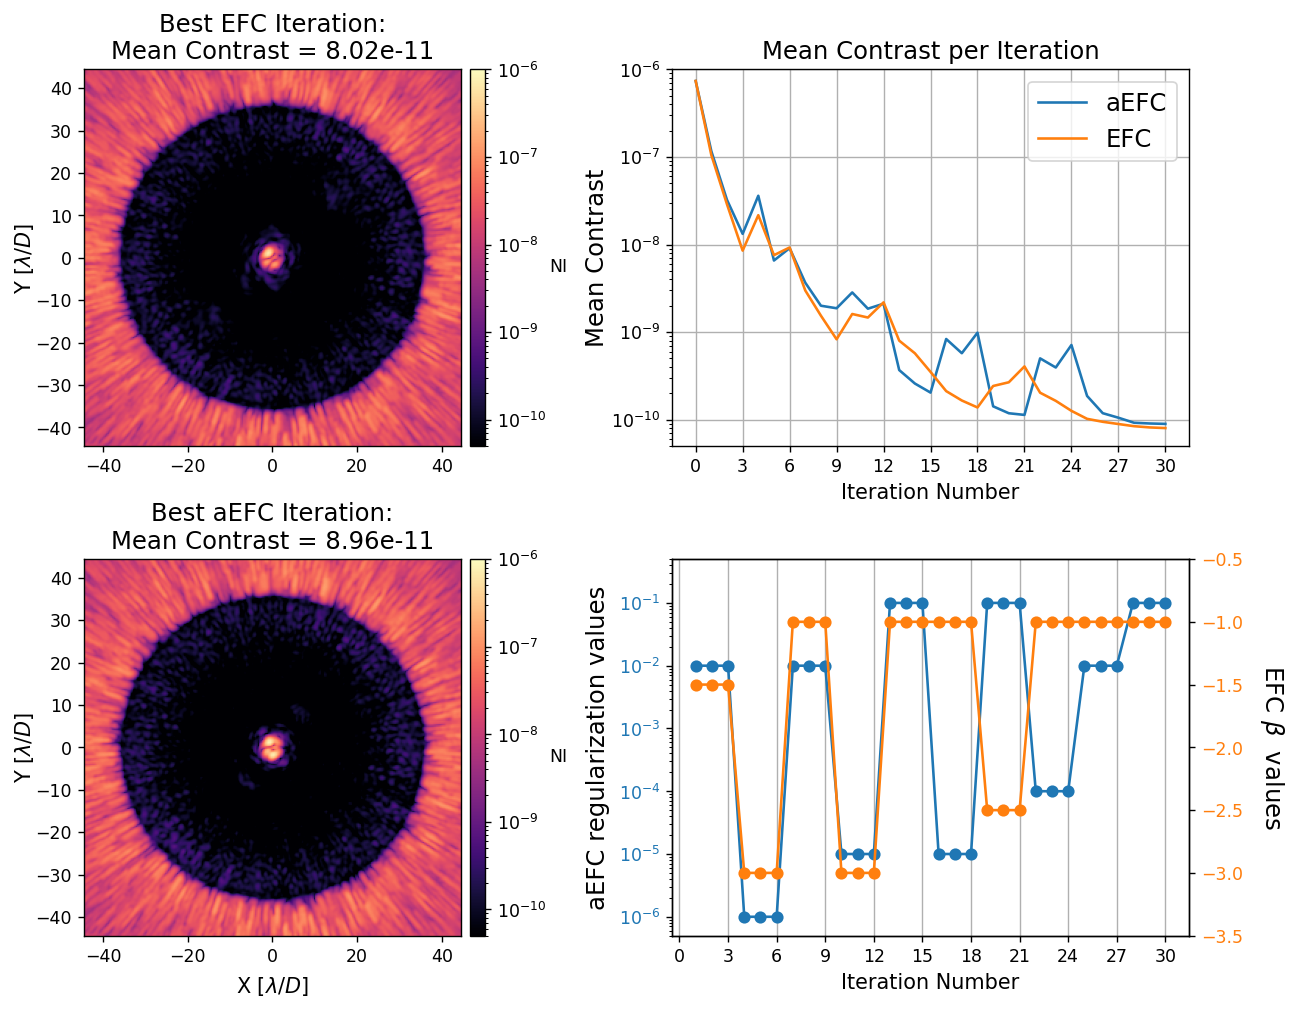

In [3]:

# efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241203}_efc_run_with_ME.pkl')
efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241220}_efc_run_with_ME_2.pkl')

# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241204}_aefc_run_with_ME_2.pkl')
# aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241220}_aefc_run_with_ME_2.pkl')

aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20250310}_aefc_run_with_ME.pkl')

import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_both_with_reg_conds(
    efc_data,  aefc_data,
    im1vmin=5e-11, im1vmax=1e-6, 
    im2vmin=5e-11, im2vmax=1e-6, 
    vmin=5e-11, vmax=1e-6,
    xticks=np.linspace(0,30,11),
    fname='../figs/sim_bb_with_me.pdf',
)

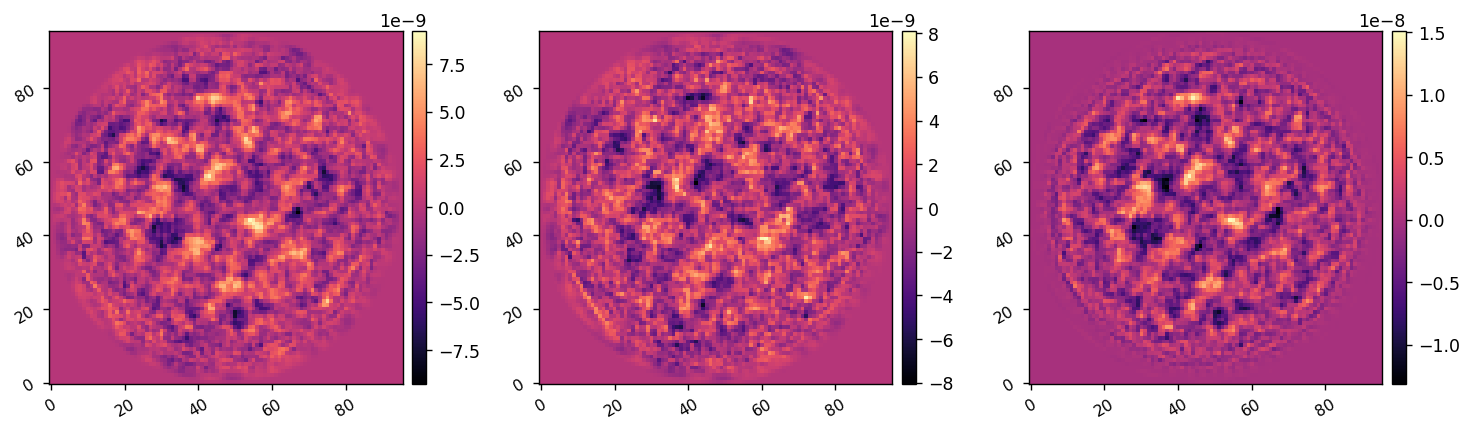

In [12]:
i = -1
imshow3(
    aefc_data['dm1_commands'][i], 
    aefc_data['dm2_commands'][i], 
    aefc_data['dm1_commands'][i]-aefc_data['dm2_commands'][i],
)

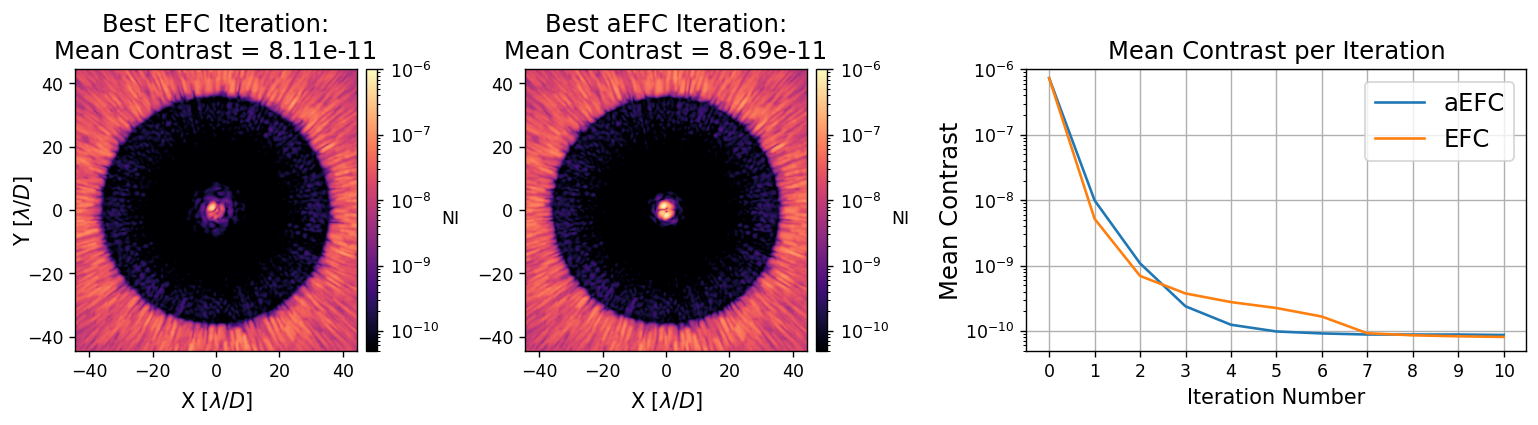

In [ ]:
efc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241203}_efc_run_without_ME.pkl')
aefc_data = utils.load_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/{20241203}_aefc_run_without_ME.pkl')

import aefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_both_data(
    efc_data,  aefc_data,
    im1vmin=5e-11, im1vmax=1e-6, 
    im2vmin=5e-11, im2vmax=1e-6, 
    vmin=5e-11, vmax=1e-6,
    xticks=np.linspace(0,10,11),
    fname='../figs/sim_bb.pdf',
)